In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All imports successful!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


All imports successful!


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Loading Data

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
import pandas as pd

path = '/content/drive/MyDrive/CSE572_Project/Resume.csv'
df=pd.read_csv(path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nJob Categories ({df['Category'].nunique()} total)")
print(df['Category'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (2484, 4)

Column names: ['ID', 'Resume_str', 'Resume_html', 'Category']

Job Categories (24 total)
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


/tmp/ipykernel_842/3653494926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


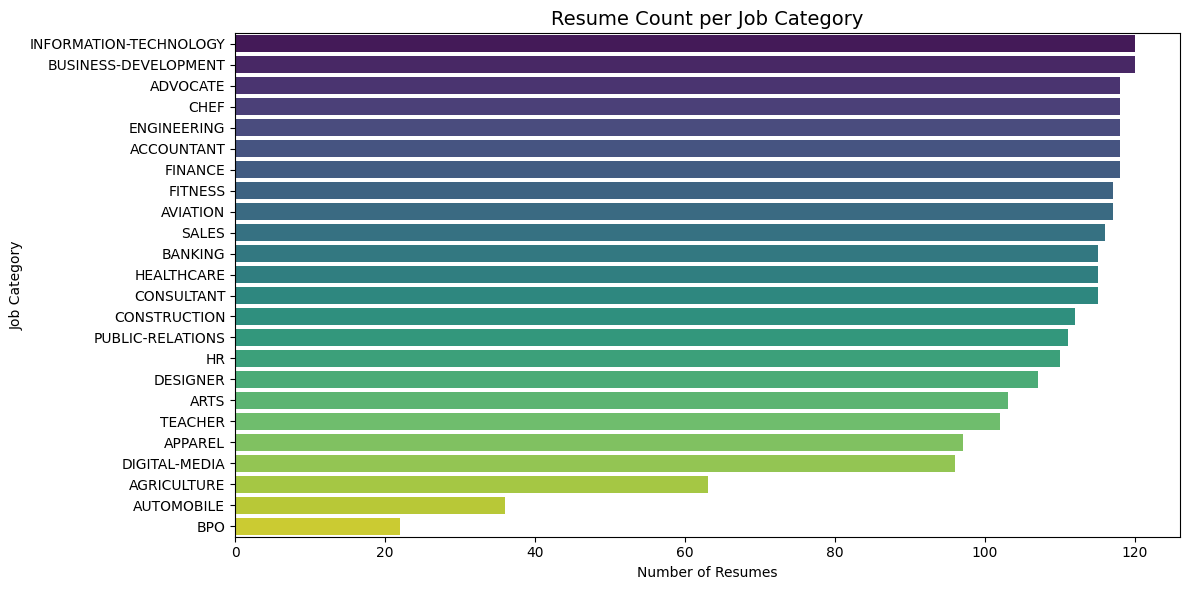

Plot saved to Drive.


In [5]:
# Class Distribution Plot
plt.figure(figsize=(12, 6))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Resume Count per Job Category', fontsize=14)
plt.xlabel('Number of Resumes')
plt.ylabel('Job Category')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CSE572_Project/class_distribution.png', dpi=150)
plt.show()
print("Plot saved to Drive.")

Text Cleaning

In [6]:
# Text Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # 4. Remove HTML tags (in case any slipped through)
    text = re.sub(r'<.*?>', '', text)
    # 5. Remove special characters and punctuation but keep numbers
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # 6. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 7. Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

# Apply to dataset
df['cleaned_text'] = df['Resume_str'].apply(clean_text)

# Quick check
print("Sample original text (first 200 chars):")
print(df['Resume_str'].iloc[0][:200])
print("\nSample cleaned text (first 200 chars):")
print(df['cleaned_text'].iloc[0][:200])

Sample original text (first 200 chars):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

Sample cleaned text (first 200 chars):
hr administratormarketing associate hr administrator summary dedicated customer service manager 15 year experience hospitality customer service management respected builder leader customerfocused team


Label Encoding and spliting data

In [7]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

print(f"Number of classes: {len(le.classes_)}")
print(f"Classes: {list(le.classes_)}")

# Stratified split: 70% train, 15% val, 15% test
X = df['cleaned_text']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain size: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Val size:   {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

Number of classes: 24
Classes: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']

Train size: 1738 (70.0%)
Val size:   373 (15.0%)
Test size:  373 (15.0%)


Saving preprocessed data to drive

In [8]:
save_path = '/content/drive/MyDrive/CSE572_Project/'

# Save full preprocessed dataframe
df[['ID', 'Category', 'label', 'cleaned_text']].to_csv(
    save_path + 'preprocessed_data.csv', index=False
)

# Save splits
pd.DataFrame({'text': X_train, 'label': y_train}).to_csv(
    save_path + 'train.csv', index=False
)
pd.DataFrame({'text': X_val, 'label': y_val}).to_csv(
    save_path + 'val.csv', index=False
)
pd.DataFrame({'text': X_test, 'label': y_test}).to_csv(
    save_path + 'test.csv', index=False
)

# Save label encoder classes
np.save(save_path + 'label_classes.npy', le.classes_)

print("All files saved to Drive:")
print("  preprocessed_data.csv")
print("  train.csv / val.csv / test.csv")
print("  label_classes.npy")

All files saved to Drive:
  preprocessed_data.csv
  train.csv / val.csv / test.csv
  label_classes.npy
